## Two One-Sided Test for Equivalence (TOST)

In [85]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms

In [86]:
import statsmodels
print(statsmodels.__version__)

0.14.1


TOST Results: (0.002500598994357302, (2.8388320559816003, 0.002500598994357302, 197.52867431439725), (-4.754695943505288, 1.9123423347029593e-06, 197.52867431439725))


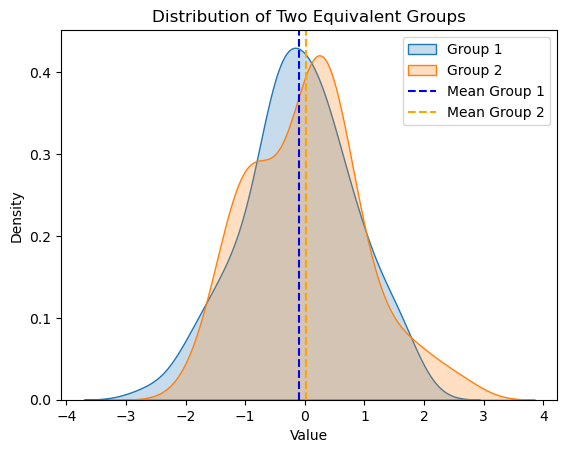

In [87]:
np.random.seed(42)

# Simulate two groups from the same normal distribution (equivalent groups)
group1 = np.random.normal(loc=0, scale=1, size=100)
group2 = np.random.normal(loc=0, scale=1, size=100)

# Define equivalence margins (delta values)
low_margin, high_margin = -0.5, 0.5

# Perform the Two One-Sided Tests (TOST) for equivalence
tost_result = sms.ttost_ind(group1, group2, low_margin, high_margin, usevar='unequal')
print("TOST Results:", tost_result)
# Expected: Both one-sided tests produce p-values < 0.05, indicating equivalence.

# Visualize the distributions of the two groups
sns.kdeplot(group1, fill=True, label='Group 1')
sns.kdeplot(group2, fill=True, label='Group 2')
plt.axvline(np.mean(group1), color='blue', linestyle='--', label='Mean Group 1')
plt.axvline(np.mean(group2), color='orange', linestyle='--', label='Mean Group 2')
plt.title("Distribution of Two Equivalent Groups")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

TOST Results: 


* Reported p-value 0.002 is the largest of the one-sided tests.
    * For equivalency to be declared at a common alpha level (ie 0.05), both tests must yield p-values below that threshold.
* First tuple is the first one-sided test that the mean of one group is greater than the lower bound:
    * t-statistic: 2.838
    * p-value: 0.002
    * dof: 198.0
* Second tuple is the second one-sided test that the mean is less than the upper bound:
    * t-statistic: -4.754
    * p-value: 1.90e-06
    * dof: 198.0


### Implemented by hand:

In [88]:
import scipy.stats as stats

In [89]:
np.random.seed(42)

# Simulate two groups from the same normal distribution (equivalent groups)
group1 = np.random.normal(loc=0, scale=1, size=100)
group2 = np.random.normal(loc=0, scale=1, size=100)

# Compute means and standard deviations
mean1, mean2 = np.mean(group1), np.mean(group2)
std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
mean1, mean2, std1, std2

(-0.10384651739409384,
 0.022304587049923885,
 0.9081684280078007,
 0.9536689661831037)

In [90]:
# Compute sample sizes
n1, n2 = len(group1), len(group2)
n1, n2

(100, 100)

In [91]:
# Compute pooled standard error
se_pooled = np.sqrt((std1**2 / n1) + (std2**2 / n2))
se_pooled

0.131691092739445

In [92]:
# Compute difference of means
mean_diff = mean1 - mean2
mean_diff

-0.12615110444401773

In [93]:
# Degrees of freedom (Welch-Satterthwaite equation for unequal variances)
df = ((std1**2 / n1 + std2**2 / n2) ** 2) / \
     (((std1**2 / n1) ** 2) / (n1 - 1) + ((std2**2 / n2) ** 2) / (n2 - 1))
df 

197.5286743143973

In [94]:
# Perform one-sided t-tests
t_stat_low = (mean_diff - low_margin) / se_pooled
t_stat_high = (mean_diff - high_margin) / se_pooled
t_stat_low, t_stat_high

(2.8388320559816007, -4.754695943505288)

In [95]:
p_low = 1 - stats.t.cdf(t_stat_low, df=df)  # One-sided test for lower margin
p_high = stats.t.cdf(t_stat_high, df=df)   # One-sided test for upper margin
p_low, p_high

(0.0025005989943572837, 1.91234233470296e-06)

In [96]:
# Overall TOST p-value (max of the two p-values)
tost_p_value = max(p_low, p_high)
tost_p_value 

0.0025005989943572837

In [97]:
tost_result

(0.002500598994357302,
 (2.8388320559816003, 0.002500598994357302, 197.52867431439725),
 (-4.754695943505288, 1.9123423347029593e-06, 197.52867431439725))

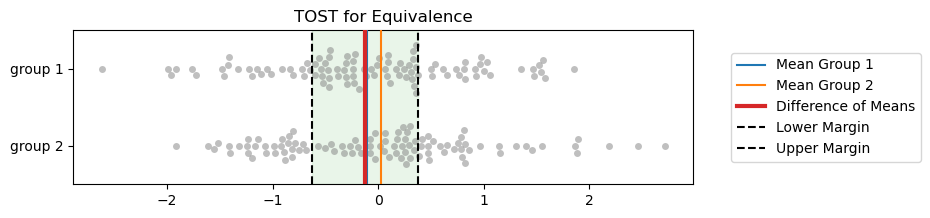

TOST Results: (0.002500598994357302, (2.8388320559816003, 0.002500598994357302, 197.52867431439725), (-4.754695943505288, 1.9123423347029593e-06, 197.52867431439725))


In [98]:
plt.figure(figsize=(8, 2))
ax = sns.swarmplot({'group 1':group1,'group 2':group2},orient='h',color='gray',alpha=0.5)
ax.axvline(mean1, color='tab:blue', label='Mean Group 1', zorder=5)
ax.axvline(mean2, color='tab:orange', label='Mean Group 2', zorder=5)

mean_diff = mean1 - mean2

# Plot difference of means and equivalence margins


ax.axvline(mean_diff, color='tab:red', label='Difference of Means', zorder=5, lw=3)

ax.axvline(mean_diff + low_margin, color='black', linestyle='--', label='Lower Margin', zorder=5)
ax.axvline(mean_diff + high_margin, color='black', linestyle='--', label='Upper Margin', zorder=5)
ax.axvspan(mean_diff + low_margin, mean_diff + high_margin, color='tab:green', alpha=0.1, zorder=-1)

plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.title("TOST for Equivalence")
plt.show()

tost_result = sms.ttost_ind(group1, group2, low_margin, high_margin, usevar='unequal')
print("TOST Results:", tost_result)

### Non-equivalent groups

In [99]:
# Set random seed for reproducibility
np.random.seed(42)

# Simulate two groups with nearly equivalent means
group1 = np.random.normal(loc=2, scale=1, size=100)
group2 = np.random.normal(loc=-1, scale=1, size=100)

In [100]:
# Perform the Two One-Sided Tests (TOST) for equivalence
tost_result = sms.ttost_ind(group1, group2, low_margin, high_margin, usevar='unequal')
print("TOST Results:", tost_result)

TOST Results: (1.0, (25.61941605444227, 5.221416664998775e-65, 197.52867431439734), (18.02588805495538, 1.0, 197.52867431439734))


In [101]:
np.random.seed(42)

# Simulate two groups from the same normal distribution (equivalent groups)
group1 = np.random.normal(loc=2, scale=1, size=100)
group2 = np.random.normal(loc=-1, scale=1, size=100)

# Compute means and standard deviations
mean1, mean2 = np.mean(group1), np.mean(group2)
std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
mean1, mean2, std1, std2

(1.8961534826059059,
 -0.9776954129500761,
 0.9081684280078007,
 0.9536689661831037)

In [102]:
n1, n2 = len(group1), len(group2)
# Compute pooled standard error
se_pooled = np.sqrt((std1**2 / n1) + (std2**2 / n2))
se_pooled

0.131691092739445

In [103]:
# Compute difference of means
mean_diff = mean1 - mean2
mean_diff

2.873848895555982

In [104]:
# Degrees of freedom (Welch-Satterthwaite equation for unequal variances)
df = ((std1**2 / n1 + std2**2 / n2) ** 2) / \
     (((std1**2 / n1) ** 2) / (n1 - 1) + ((std2**2 / n2) ** 2) / (n2 - 1))
df 

197.5286743143973

In [105]:
# Perform one-sided t-tests
t_stat_low = (mean_diff - low_margin) / se_pooled
t_stat_high = (mean_diff - high_margin) / se_pooled
t_stat_low, t_stat_high

(25.619416054442265, 18.025888054955377)

In [106]:
p_low = 1 - stats.t.cdf(t_stat_low, df=df)  # One-sided test for lower margin
p_high = stats.t.cdf(t_stat_high, df=df)   # One-sided test for upper margin
p_low, p_high

(0.0, 1.0)

In [107]:
# Overall TOST p-value (max of the two p-values)
tost_p_value = max(p_low, p_high)
tost_p_value 

1.0

In [108]:
tost_result

(1.0,
 (25.61941605444227, 5.221416664998775e-65, 197.52867431439734),
 (18.02588805495538, 1.0, 197.52867431439734))

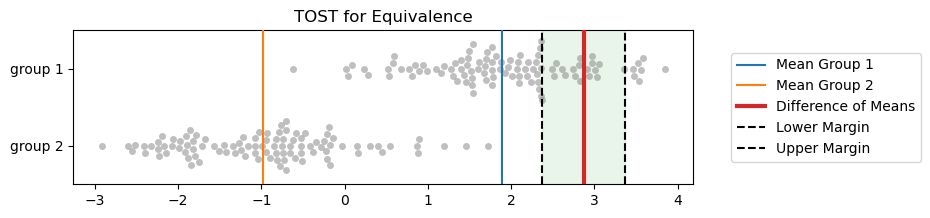

TOST Results: (1.0, (25.61941605444227, 5.221416664998775e-65, 197.52867431439734), (18.02588805495538, 1.0, 197.52867431439734))


In [109]:
# Simulate two groups with nearly equivalent means
np.random.seed(42)
group1 = np.random.normal(loc=2, scale=1, size=100)
group2 = np.random.normal(loc=-1, scale=1, size=100)

mean1 = np.mean(group1)
mean2 = np.mean(group2)

plt.figure(figsize=(8, 2))
ax = sns.swarmplot({'group 1':group1,'group 2':group2},orient='h',color='gray',alpha=0.5)
ax.axvline(mean1, color='tab:blue', label='Mean Group 1', zorder=5)
ax.axvline(mean2, color='tab:orange', label='Mean Group 2', zorder=5)

mean_diff = mean1 - mean2

# Plot difference of means and equivalence margins


ax.axvline(mean_diff, color='tab:red', label='Difference of Means', zorder=5, lw=3)

ax.axvline(mean_diff + low_margin, color='black', linestyle='--', label='Lower Margin', zorder=5)
ax.axvline(mean_diff + high_margin, color='black', linestyle='--', label='Upper Margin', zorder=5)
ax.axvspan(mean_diff + low_margin, mean_diff + high_margin, color='tab:green', alpha=0.1, zorder=-1)

plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.title("TOST for Equivalence")
plt.show()

tost_result = sms.ttost_ind(group1, group2, low_margin, high_margin, usevar='unequal')
print("TOST Results:", tost_result)

------

In [119]:
# https://rowannicholls.github.io/python/statistics/hypothesis_testing/tost_unpaired.html



a = [4, 7, 8, 6, 3, 2]
b = [6, 8, 7, 10, 11, 9]

tost_result = sms.ttost_ind(a,b, -1, 1, usevar='unequal')
tost_result

(0.9643478849753625,
 (-2.029994857352875, 0.9643478849753625, 9.494382022471909),
 (-3.6539907432351755, 0.0024157337481363838, 9.494382022471909))

In [130]:
# TOST

### This approach uses the pooled variance

# Magnitude of region of similarity
bound = 1
# Unpaired two-sample t-test
_, p_greater = stats.ttest_ind(np.array(a) + bound, b, alternative='greater')
_, p_less = stats.ttest_ind(np.array(a) - bound, b, alternative='less')
# Choose the maximum p-value
pval = max(p_less, p_greater)
pval

0.9650973998091475

In [131]:
### in the ttost_ind function we can specify either pooled or unequal variance
tost_result = sms.ttost_ind(a, b, -1, 1, usevar='pooled')
print("TOST Results:", tost_result)

TOST Results: (0.9650973998091475, (-2.029994857352875, 0.9650973998091475, 10.0), (-3.6539907432351755, 0.002216465482443902, 10.0))


In [132]:
tost_result = sms.ttost_ind(a, b, -1, 1, usevar='unequal')
print("TOST Results:", tost_result)

TOST Results: (0.9643478849753625, (-2.029994857352875, 0.9643478849753625, 9.494382022471909), (-3.6539907432351755, 0.0024157337481363838, 9.494382022471909))


In [133]:
# Sample means
mean_a = np.mean(a)
mean_b = np.mean(b)
# Sample sizes
sample_size_a = len(a)
sample_size_b = len(b)
# Sample variances
var_a = np.var(a, ddof=1)
var_b = np.var(b, ddof=1)
# Pooled sample variance (ie we assume equal variances)
var_p = ((sample_size_a - 1) * var_a + (sample_size_b - 1) * var_b) / (sample_size_a + sample_size_b - 2)
# Pooled sample standard deviation
std_p = np.sqrt(var_p)
# t-Values
bound = 1
t_1 = (mean_a - mean_b + bound) / np.sqrt(var_p / sample_size_a + var_p / sample_size_b)
t_2 = (mean_a - mean_b - bound) / np.sqrt(var_p / sample_size_a + var_p / sample_size_b)
# Degrees of freedom
dof = sample_size_a + sample_size_b - 2
# Critical values of the t distribution
alpha_1 = 0.05
t_crit_1 = stats.t.ppf(1 - alpha_1, dof)
alpha_2 = 1 - alpha_1
t_crit_2 = stats.t.ppf(1 - alpha_2, dof)
# Test the t-statistics against the t-values required for significance
if (t_1 > t_crit_1) and (t_2 < t_crit_2):
    print('Reject both null hypotheses; the means of the two samples are equivalent')
else:
    print('Fail to reject both null hypotheses; the means of the two samples are not equivalent')

Fail to reject both null hypotheses; the means of the two samples are not equivalent


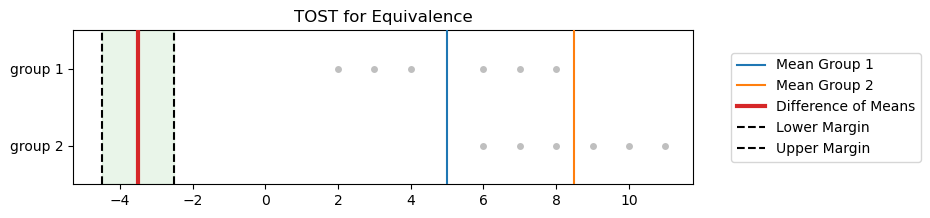

TOST Results: (0.9643478849753625, (-2.029994857352875, 0.9643478849753625, 9.494382022471909), (-3.6539907432351755, 0.0024157337481363838, 9.494382022471909))


In [140]:
# Simulate two groups with nearly equivalent means

low_margin=-1
high_margin=1
group1 = a
group2 = b

mean1 = np.mean(group1)
mean2 = np.mean(group2)

plt.figure(figsize=(8, 2))
ax = sns.swarmplot({'group 1':group1,'group 2':group2},orient='h',color='gray',alpha=0.5)
ax.axvline(mean1, color='tab:blue', label='Mean Group 1', zorder=5)
ax.axvline(mean2, color='tab:orange', label='Mean Group 2', zorder=5)

mean_diff = mean1 - mean2

# Plot difference of means and equivalence margins


ax.axvline(mean_diff, color='tab:red', label='Difference of Means', zorder=5, lw=3)

ax.axvline(mean_diff + low_margin, color='black', linestyle='--', label='Lower Margin', zorder=5)
ax.axvline(mean_diff + high_margin, color='black', linestyle='--', label='Upper Margin', zorder=5)
ax.axvspan(mean_diff + low_margin, mean_diff + high_margin, color='tab:green', alpha=0.1, zorder=-1)

plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.title("TOST for Equivalence")
plt.show()

tost_result = sms.ttost_ind(group1, group2, low_margin, high_margin, usevar='unequal')
print("TOST Results:", tost_result)

------

In [ ]:
## https://real-statistics.com/students-t-distribution/equivalence-testing-tost/

In [147]:
a = [2311, 2274, 2262, 2297, 2291, 2319, 2263, 2329, 2289, 2287, 2290, 2301]
b = [2298, 2260, 2250, 2242, 2302, 2297, 2293, 2286, 2270, 2313, 2327, 2290]

In [152]:
mean_a, mean_b = np.mean(a), np.mean(b)
mean_a, mean_b

(2292.75, 2285.6666666666665)

In [148]:
tost_result = sms.ttost_ind(a, b, -25, 25, usevar='unequal')
print("TOST Results:", tost_result)

TOST Results: (0.03607016315649114, (3.390321401941906, 0.0013758935743379763, 21.06069934818252), (-1.8932963673181822, 0.03607016315649114, 21.06069934818252))


In [149]:
tost_result = sms.ttost_ind(a, b, -25, 25, usevar='pooled')
print("TOST Results:", tost_result)

TOST Results: (0.03577310618103932, (3.390321401941906, 0.0013156895696120347, 22.0), (-1.8932963673181822, 0.03577310618103932, 22.0))


TOST Results: (8.41087623687451e-10, (11.315748055832039, 6.085697497909697e-11, 22.0), (-9.818723021208314, 8.41087623687451e-10, 22.0))


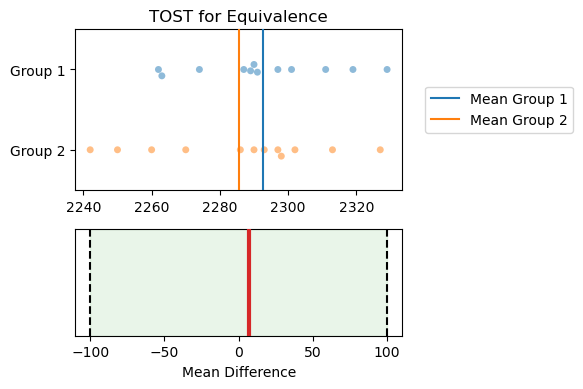

In [171]:
# Simulate two groups with nearly equivalent means

low_margin=-100
high_margin=100

group1 = a
group2 = b

mean1 = np.mean(group1)
mean2 = np.mean(group2)


# Create figure with two vertically stacked subplots
fig, axes = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={'height_ratios': [0.75, 0.5]}, sharex=False)

# Panel 1: Swarm plot
sns.swarmplot(data=[group1, group2], orient='h', ax=axes[0], palette=['tab:blue', 'tab:orange'], alpha=0.5)
axes[0].axvline(mean1, color='tab:blue', label='Mean Group 1', zorder=5)
axes[0].axvline(mean2, color='tab:orange', label='Mean Group 2', zorder=5)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["Group 1", "Group 2"])
axes[0].set_title("TOST for Equivalence")

# Panel 2: Mean difference and equivalence margins
axes[1].axvline(mean_diff, color='tab:red', label='Difference of Means', lw=3, zorder=5)
axes[1].axvline(low_margin, color='black', linestyle='--', label='Lower Margin', zorder=5)
axes[1].axvline(high_margin, color='black', linestyle='--', label='Upper Margin', zorder=5)
axes[1].axvspan(low_margin, high_margin, color='tab:green', alpha=0.1, zorder=-1)
axes[1].set_yticks([])  # Remove y-axis labels for clarity
axes[1].set_xlabel("Mean Difference")

# Add legend only once
#handles, labels = axes[1].get_legend_handles_labels()
#axes[0].legend(handles, labels, loc='center right')

axes[0].legend(bbox_to_anchor=(1.05, 0.5), loc='center left',)


tost_result = sms.ttost_ind(a, b, low_margin, high_margin, usevar='pooled')
print("TOST Results:", tost_result)

plt.tight_layout()
plt.show()

<Axes: >

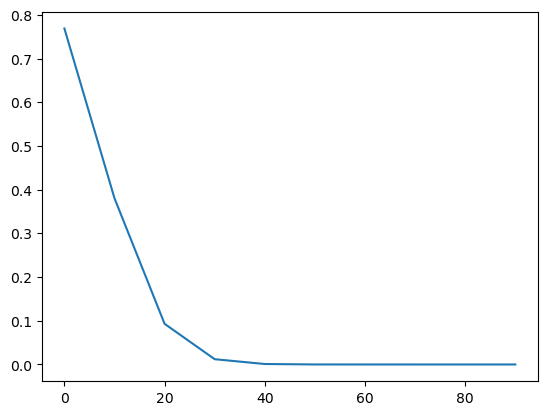

In [175]:


tost_res = {}
for margin in range(0, 100, 10):

    low_margin=-margin
    high_margin=margin

    group1 = a
    group2 = b

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    tost_result = sms.ttost_ind(a, b, low_margin, high_margin, usevar='pooled')
    
    tost_res[margin] = tost_result[0]

sns.lineplot(x=list(tost_res.keys()), y=list(tost_res.values()))    

0.7689604991819997